In [ ]:
# --- CELL 1: FORCE INSTALLATION (NO GITHUB) ---
import os

print("🛑 Cleaning up...")
os.system("pip uninstall numpy pandas-ta yfinance -y")

print("⬇️ Installing Numpy 1.x (Zaroori hai)...")
!pip install "numpy<2.0"

print("⬇️ Installing pandas_ta (The Cheat Code)...")
# --no-deps ka matlab: "Dependency check mat karo, bas chup chap install karo"
!pip install pandas_ta --no-deps

print("⬇️ Installing Baqi Cheezein...")
!pip install yfinance "websockets>=13.0"

print("\n" + "="*50)
print("✅ INSTALLATION DONE (Bina GitHub ke)")
print("⚠️ AB SIRF EK BAAR 'RUNTIME > RESTART SESSION' KAREIN.")
print("="*50)

🛑 Cleaning up...
⬇️ Installing Numpy 1.x (Zaroori hai)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 

⬇️ Installing pandas_ta (The Cheat Code)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 23.5 MB/s eta 0:00:00
⬇️ Installing Baqi Cheezein...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 11.6 MB/s eta 0:00:00


KeyboardInterrupt: 

Mounted at /content/drive
📂 ROOT: /content/drive/MyDrive/ARVisionGold

🚀 SYSTEM READY FOR SUPERVISOR (Final Version)
Upload Chart Image below:


Saving Screenshot 2025-12-03 101539.png to Screenshot 2025-12-03 101539.png


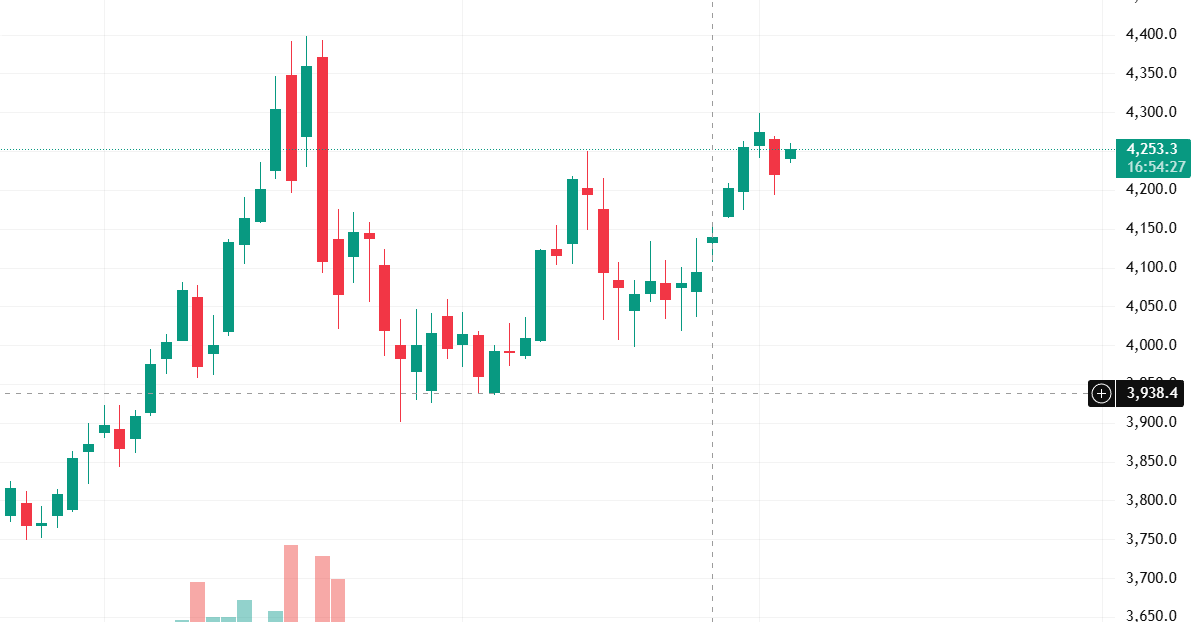

🤖 AI: Data fetch kar raha hoon (1 Year)...


/tmp/ipython-input-667959393.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="2y", interval="1d", progress=False)


👁️ Vision: Image dekh raha hoon...

████████████████████████████████████████
💰 Market Price: $4253.10
🤖 AI Prediction: DOWN 📉
👁️ Chart Candle:  RED (Bearish)
----------------------------------------
📢 FINAL SIGNAL:  STRONG SELL ❌
████████████████████████████████████████


In [1]:
# --- CELL 2: MASTER DEMO (FIXED AI LOGIC) ---
import os
import sys
import cv2
import yaml
import joblib
import numpy as np
import pandas as pd
import yfinance as yf
# Pandas TA fallback logic
try:
    import pandas_ta as ta
except ImportError:
    pass

from google.colab import drive
from google.colab import files
from IPython.display import display, Image

# 1. Drive Mount
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/MyDrive/ARVisionGold"
print(f"📂 ROOT: {ROOT}")

# 2. Config Load
try:
    with open(f"{ROOT}/configs/paths.yaml") as f: P = yaml.safe_load(f)
    with open(f"{ROOT}/configs/model.yaml") as f: MCFG = yaml.safe_load(f)
    MODEL_PATH = P["artifacts"]["model_rf"]
except Exception as e:
    print(f"❌ Config Error: {e}")

# -------------------------------------------------
# 3. AI LOGIC (FIXED)
# -------------------------------------------------
def get_ai_prediction():
    print("🤖 AI: Data fetch kar raha hoon (1 Year)...")
    try:
        # FIX: Period ko '100d' se barha kar '2y' (2 saal) kar diya hai
        # Taake indicators (SMA 50) ke liye data kam na pare.
        df = yf.download("GC=F", period="2y", interval="1d", progress=False)

        if df.empty:
            return "DATA ERROR", 0.0

        # Handle YFinance MultiIndex (Agar naya version column issue kare)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Basic Indicators Logic
        close = df['Close']

        # Indicator 1: RSI
        if 'ta' in globals():
            df['RSI'] = ta.rsi(close, length=14)
        else:
            # Manual RSI Calculation (Agar library fail ho)
            delta = close.diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
            rs = gain / loss
            df['RSI'] = 100 - (100 / (1 + rs))

        # Indicator 2 & 3: Moving Averages
        df['SMA_50'] = close.rolling(window=50).mean()
        df['EMA_20'] = close.ewm(span=20, adjust=False).mean()

        # FIX: Dropna ke baad check karo ke kuch bacha bhi hai ya nahi
        df.dropna(inplace=True)

        if len(df) == 0:
            return "NOT ENOUGH DATA", 0.0

        # Last Row (Latest Market Status)
        last_row = df.iloc[[-1]].copy()
        current_price = float(last_row['Close'].values[0])

        # Model Prediction
        if os.path.exists(MODEL_PATH):
            rf = joblib.load(MODEL_PATH)

            # Features match karna
            features = getattr(rf, "feature_names_in_", MCFG["features"]["include"])
            for f in features:
                if f not in last_row: last_row[f] = 0

            pred = rf.predict(last_row[features])[0]
            return ("UP 📈" if pred == 1 else "DOWN 📉"), current_price
        else:
            return "MODEL MISSING", current_price

    except Exception as e:
        print(f"AI Error Details: {e}")
        return "ERROR", 0.0

# -------------------------------------------------
# 4. CV LOGIC
# -------------------------------------------------
def analyze_image(img_path):
    print("👁️ Vision: Image dekh raha hoon...")
    img = cv2.imread(img_path)
    if img is None: return "Bad Image"

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Green Mask
    mask_green = cv2.inRange(hsv, (40, 40, 40), (80, 255, 255))
    # Red Mask
    mask_red1 = cv2.inRange(hsv, (0, 50, 50), (10, 255, 255))
    mask_red2 = cv2.inRange(hsv, (170, 50, 50), (180, 255, 255))

    g = cv2.countNonZero(mask_green)
    r = cv2.countNonZero(mask_red1 + mask_red2)

    if g > r: return "GREEN (Bullish)"
    elif r > g: return "RED (Bearish)"
    return "Neutral"

# -------------------------------------------------
# 5. EXECUTION
# -------------------------------------------------
print("\n🚀 SYSTEM READY FOR SUPERVISOR (Final Version)")
print("Upload Chart Image below:")

uploaded = files.upload()

for fn in uploaded.keys():
    display(Image(fn, width=400))

    trend, price = get_ai_prediction()
    candle = analyze_image(fn)

    final = "WAIT ⚠️"
    color = "black"

    # Confluence Logic (Jahan dono agree karein)
    if "UP" in trend and "GREEN" in candle:
        final = "STRONG BUY ✅"
    elif "DOWN" in trend and "RED" in candle:
        final = "STRONG SELL ❌"

    print("\n" + "█"*40)
    print(f"💰 Market Price: ${price:.2f}")
    print(f"🤖 AI Prediction: {trend}")
    print(f"👁️ Chart Candle:  {candle}")
    print("-" * 40)
    print(f"📢 FINAL SIGNAL:  {final}")
    print("█"*40)
    os.remove(fn)

📂 Mounting Google Drive...
Mounted at /content/drive
✅ Configs Loaded from YAML.
📂 Looking for Model at: /content/drive/MyDrive/ARVisionGold/artifacts/models/gold_price_predictor.joblib
⏳ Downloading Test Data (1 Year)...
🤖 Running Predictions...


/tmp/ipython-input-2023586665.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GC=F", period="1y", interval="1d", progress=False)



██████████████████████████████████████████████████
🎯 ACCURACY SCORE: 42.50%
██████████████████████████████████████████████████

📊 Classification Report:
              precision    recall  f1-score   support

        DOWN       0.42      1.00      0.59        84
          UP       1.00      0.01      0.02       116

    accuracy                           0.42       200
   macro avg       0.71      0.50      0.31       200
weighted avg       0.76      0.42      0.26       200



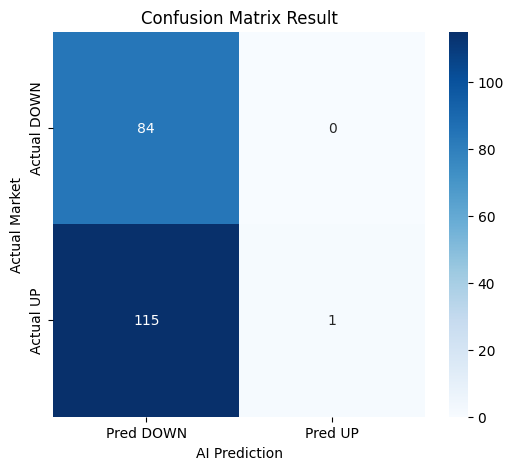

In [ ]:
# --- CELL 3: ACCURACY CHECKER (FIXED & ROBUST) ---
import os
import sys
import joblib
import yaml
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import drive

# 1. Drive Mount (Zaroori hai)
if not os.path.exists('/content/drive'):
    print("📂 Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/MyDrive/ARVisionGold"

# 2. Path Setup (Manual Fallback)
# Agar config file fail ho jaye, to hum hardcoded path use karenge
try:
    with open(f"{ROOT}/configs/paths.yaml") as f: P = yaml.safe_load(f)
    MODEL_PATH = P["artifacts"]["model_rf"]
    print("✅ Configs Loaded from YAML.")
except Exception as e:
    print(f"⚠️ Config Load Failed ({e}). Using Manual Path.")
    # Yeh woh path hai jo humne structure mein banaya tha
    MODEL_PATH = f"{ROOT}/artifacts/models/gold_price_predictor.joblib"

print(f"📂 Looking for Model at: {MODEL_PATH}")

if not os.path.exists(MODEL_PATH):
    print("❌ ERROR: Model file abhi bhi nahi mili!")
    print("Please check ke 'artifacts/models' folder mein file mojood hai.")
    sys.exit()

# 3. Download Data (Last 1 Year for Testing)
print("⏳ Downloading Test Data (1 Year)...")
df = yf.download("GC=F", period="1y", interval="1d", progress=False)

# MultiIndex fix for new yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 4. Feature Engineering (Training jaisa same hona chahiye)
close = df['Close']

# RSI Calculation
try:
    import pandas_ta as ta
    df['RSI'] = ta.rsi(close, length=14)
except:
    # Manual RSI if lib missing
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

df['SMA_50'] = close.rolling(50).mean()
df['EMA_20'] = close.ewm(span=20).mean()

# Target Create (Next Day Up/Down)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df.dropna(inplace=True)

# 5. Load Model & Predict
print("🤖 Running Predictions...")
rf = joblib.load(MODEL_PATH)

# Features Alignment
# Model se poocho usay kya features chahiye
try:
    needed_features = rf.feature_names_in_
except:
    # Agar model purana hai to manually define karo
    needed_features = ['Open', 'High', 'Low', 'Close', 'RSI', 'SMA_50', 'EMA_20']

# Dataframe me missing columns ko 0 karo
for f in needed_features:
    if f not in df.columns:
        df[f] = 0

X_test = df[needed_features]
y_true = df['Target']
y_pred = rf.predict(X_test)

# 6. Generate Report
acc = accuracy_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print("\n" + "█"*50)
print(f"🎯 ACCURACY SCORE: {acc * 100:.2f}%")
print("█"*50)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['DOWN', 'UP']))

# 7. Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['Actual DOWN', 'Actual UP'])
plt.title('Confusion Matrix Result')
plt.xlabel('AI Prediction')
plt.ylabel('Actual Market')
plt.show()